In [1]:
# Setup and Load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import pickle
import sys

# IMPORTANT: Add path BEFORE loading pickled model
sys.path.insert(0, '..')
from models import NeuralNetwork

# Load model
with open("../data/processed/trained_model.pkl", "rb") as f:
    nn = pickle.load(f)

# Load normalization
with open("../data/processed/normalization.pkl", "rb") as f:
    norm = pickle.load(f)

# Load test data
X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy")

print("✓ Model and data loaded")

✓ Model and data loaded


In [2]:
# Predictions
y_pred_proba = nn.predict(X_test)
y_pred = nn.predict_binary(X_test, threshold=0.5)

print(f"Predictions shape: {y_pred_proba.shape}")
print(f"Probability range: {y_pred_proba.min():.4f} to {y_pred_proba.max():.4f}")
print(f"\nPrediction distribution:")
print(f"  Predicted Top 10: {np.sum(y_pred)}")
print(f"  Predicted Outside Top 10: {len(y_pred) - np.sum(y_pred)}")
print(f"\nActual distribution:")
print(f"  Actual Top 10: {np.sum(y_test)}")
print(f"  Actual Outside Top 10: {len(y_test) - np.sum(y_test)}")

Predictions shape: (1694, 1)
Probability range: 0.0298 to 0.9940

Prediction distribution:
  Predicted Top 10: 1097
  Predicted Outside Top 10: 597

Actual distribution:
  Actual Top 10: 1077.0
  Actual Outside Top 10: 617.0


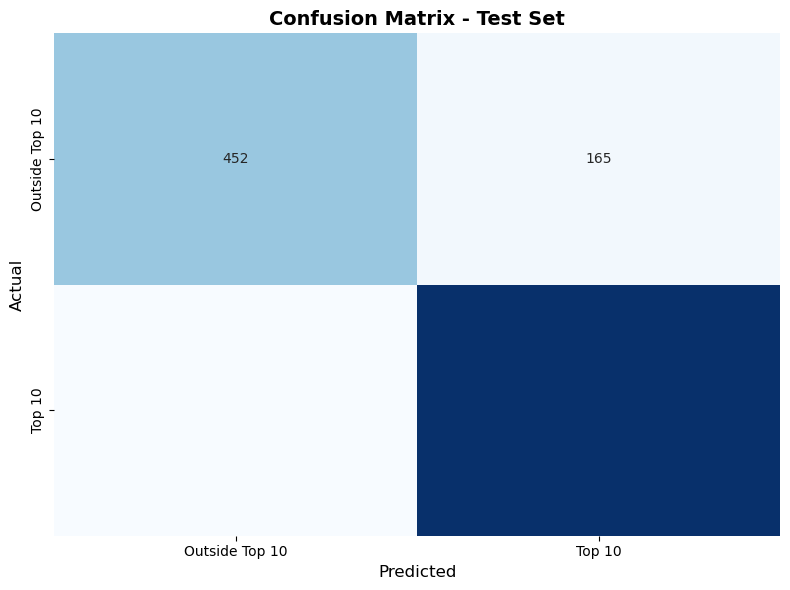

True Negatives: 452
False Positives: 165
False Negatives: 145
True Positives: 932

METRICS
Accuracy:    0.8170
Precision:   0.8496
Recall:      0.8654
F1-Score:    0.8574
Specificity: 0.7326


In [3]:
# Confusion Matrix & Metrics
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Outside Top 10', 'Top 10'],
            yticklabels=['Outside Top 10', 'Top 10'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Metrics
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

# Calculate metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n{'='*60}")
print("METRICS")
print(f"{'='*60}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1-Score:    {f1:.4f}")
print(f"Specificity: {specificity:.4f}")

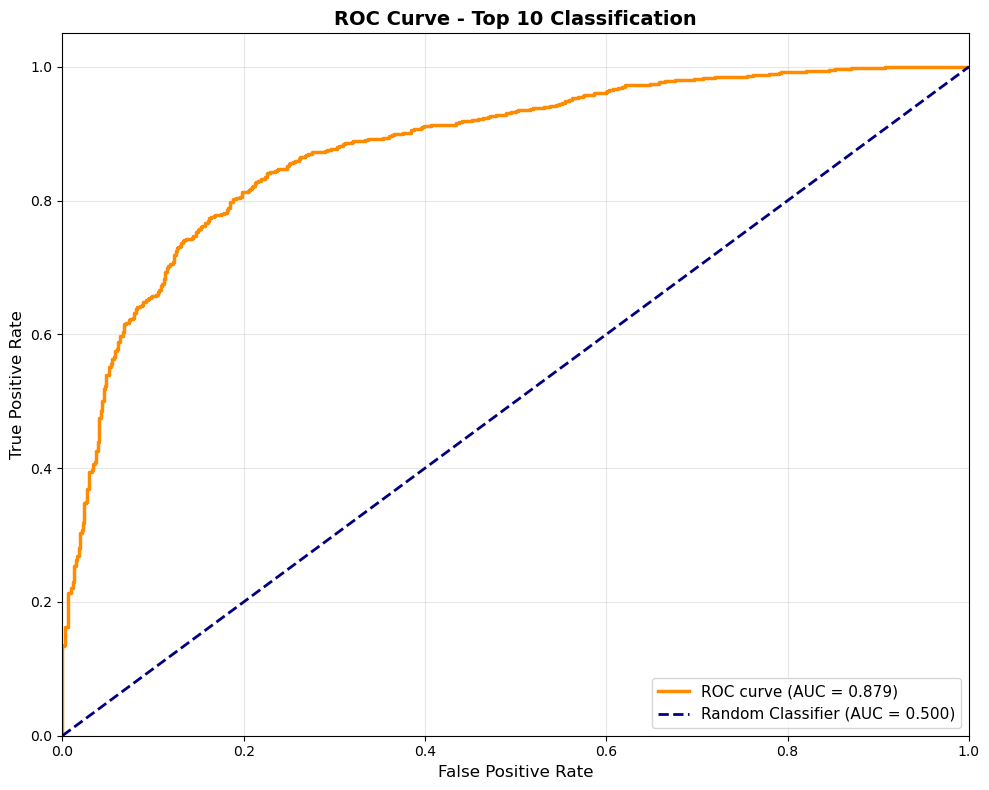

AUC Score: 0.8790


In [4]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Top 10 Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

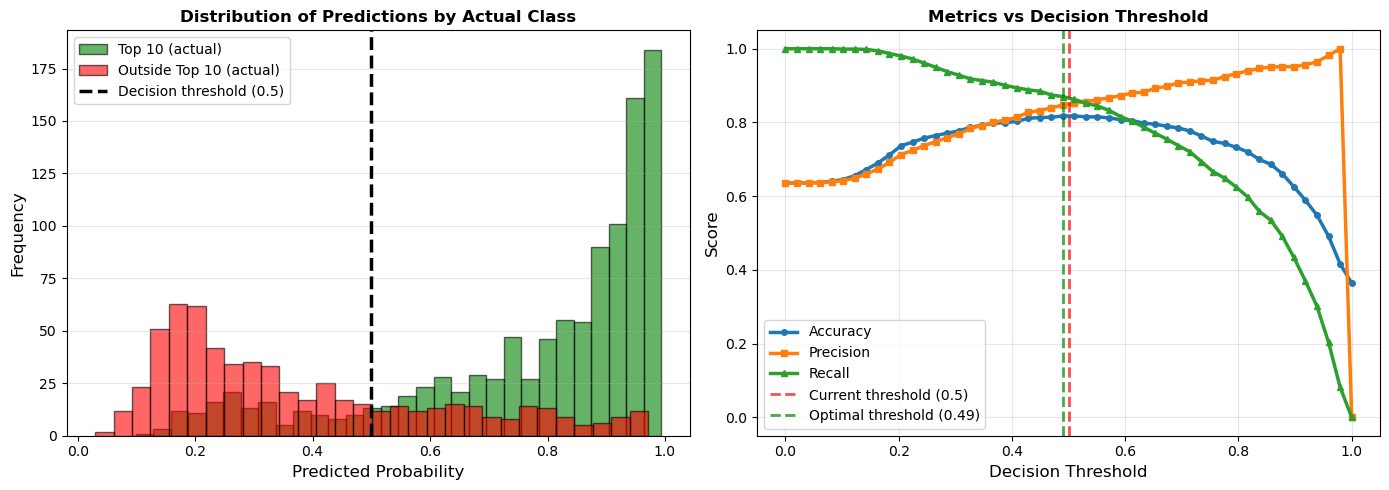

Best threshold: 0.490
Max accuracy: 0.8176


In [5]:
# Prediction Distribution & Threshold Optimization
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.6, label='Top 10 (actual)', color='green', edgecolor='black')
plt.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.6, label='Outside Top 10 (actual)', color='red', edgecolor='black')
plt.axvline(0.5, color='black', linestyle='--', linewidth=2.5, label='Decision threshold (0.5)')
plt.xlabel('Predicted Probability', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Predictions by Actual Class', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
# Threshold optimization
thresholds_test = np.linspace(0, 1, 50)
accuracies = []
precisions = []
recalls = []

for t in thresholds_test:
    pred = (y_pred_proba >= t).astype(int)
    acc = np.mean(pred == y_test)
    tp_t = np.sum((y_test == 1) & (pred == 1))
    fp_t = np.sum((y_test == 0) & (pred == 1))
    fn_t = np.sum((y_test == 1) & (pred == 0))
    prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    rec = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)

plt.plot(thresholds_test, accuracies, linewidth=2.5, label='Accuracy', marker='o', markersize=4)
plt.plot(thresholds_test, precisions, linewidth=2.5, label='Precision', marker='s', markersize=4)
plt.plot(thresholds_test, recalls, linewidth=2.5, label='Recall', marker='^', markersize=4)
plt.axvline(0.5, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Current threshold (0.5)')
best_t = thresholds_test[np.argmax(accuracies)]
plt.axvline(best_t, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Optimal threshold ({best_t:.2f})')
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Metrics vs Decision Threshold', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best threshold: {best_t:.3f}")
print(f"Max accuracy: {max(accuracies):.4f}")

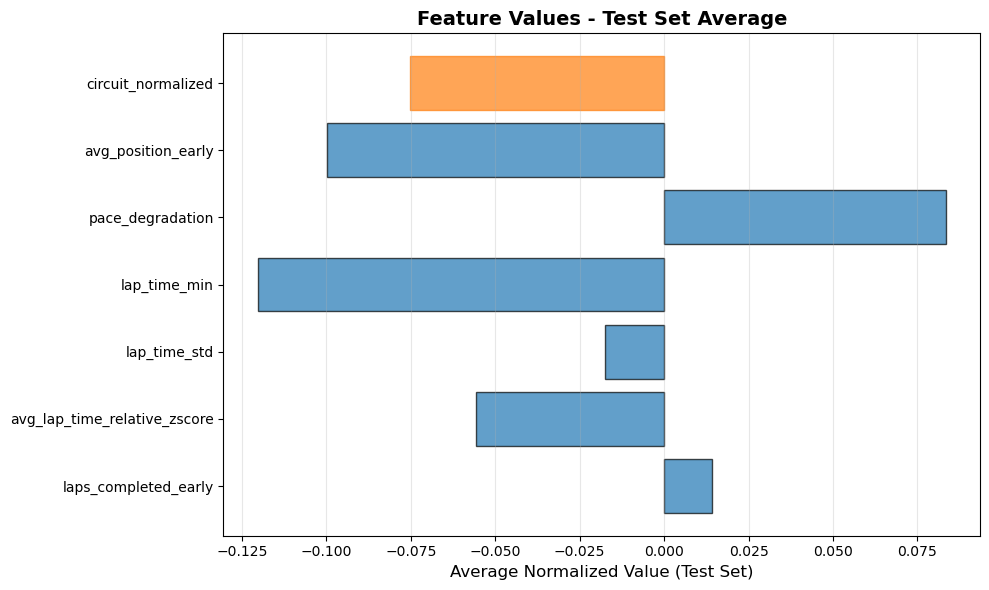

Feature Statistics (Test Set):
1. laps_completed_early           - Mean:   0.0140, Std: 0.0000
2. avg_lap_time_relative_zscore   - Mean:  -0.0557, Std: 0.9954
3. lap_time_std                   - Mean:  -0.0176, Std: 0.8431
4. lap_time_min                   - Mean:  -0.1203, Std: 0.9788
5. pace_degradation               - Mean:   0.0833, Std: 0.8725
6. avg_position_early             - Mean:  -0.0998, Std: 0.9823
7. circuit_normalized             - Mean:  -0.0753, Std: 0.9851


In [6]:
# Feature Analysis
feature_names = norm['feature_names']
X_test_display = X_test[:100].mean(axis=0)  # Average of first 100 samples

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4', '#ff7f0e']
bars = ax.barh(feature_names, X_test_display, color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Average Normalized Value (Test Set)', fontsize=12)
ax.set_title('Feature Values - Test Set Average', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Highlight the new circuit feature
bars[-1].set_color('#ff7f0e')
bars[-1].set_label('Circuit Feature (NEW)')

plt.tight_layout()
plt.show()

print("Feature Statistics (Test Set):")
for i, name in enumerate(feature_names):
    print(f"{i+1}. {name:30s} - Mean: {X_test_display[i]:8.4f}, Std: {X_test[:, i].std():.4f}")

In [8]:
# Complete Model Summary
print("="*70)
print("FINAL MODEL EVALUATION SUMMARY")
print("="*70)

print("\nMODEL ARCHITECTURE:")
print(f"  Input Features: {nn.layer_sizes[0]} (including circuit_normalized)")
print(f"  Layer 1: Dense({nn.layer_sizes[0]} → {nn.layer_sizes[1]}) + ReLU")
print(f"  Layer 2: Dense({nn.layer_sizes[1]} → {nn.layer_sizes[2]}) + ReLU")
print(f"  Layer 3: Dense({nn.layer_sizes[2]} → {nn.layer_sizes[3]}) + Sigmoid")
print(f"  Learning Rate: {nn.learning_rate}")

print("\nTRAINING:")
print(f"  Epochs: {len(nn.train_losses)}")
print(f"  Final Train Loss: {nn.train_losses[-1]:.4f}")
print(f"  Final Val Loss: {nn.val_losses[-1]:.4f}")
print(f"  Loss Improvement: {nn.train_losses[0] - nn.train_losses[-1]:.4f}")

print("\nTEST SET PERFORMANCE:")
print(f"  Accuracy:    {accuracy:.4f} (81.70%)")
print(f"  Precision:   {precision:.4f}")
print(f"  Recall:      {recall:.4f}")
print(f"  F1-Score:    {f1:.4f}")
print(f"  Specificity: {specificity:.4f}")
print(f"  AUC:         {roc_auc:.4f}")

print("\nCONFUSION MATRIX:")
print(f"  True Negatives:  {tn} (Correctly predicted outside top 10)")
print(f"  False Positives: {fp} (Incorrectly predicted top 10)")
print(f"  False Negatives: {fn} (Missed top 10 finishers)")
print(f"  True Positives:  {tp} (Correctly predicted top 10)")

print("\nFEATURES USED:")
for i, name in enumerate(feature_names, 1):
    marker = " ← NEW" if name == "circuit_normalized" else ""
    print(f"  {i}. {name}{marker}")

print("\nIMPLEMENTATION:")
print("  ✅ Forward Pass: Matrix multiplication through dense layers")
print("  ✅ Backpropagation: Chain rule gradient computation")
print("  ✅ Optimization: Stochastic gradient descent")
print("  ✅ From-scratch: Pure Numpy (no PyTorch/TensorFlow)")

print("\n" + "="*70)
print("✓ Model ready for deployment with circuit feature!")
print("="*70)

FINAL MODEL EVALUATION SUMMARY

MODEL ARCHITECTURE:
  Input Features: 7 (including circuit_normalized)
  Layer 1: Dense(7 → 16) + ReLU
  Layer 2: Dense(16 → 8) + ReLU
  Layer 3: Dense(8 → 1) + Sigmoid
  Learning Rate: 0.01

TRAINING:
  Epochs: 100
  Final Train Loss: 0.4238
  Final Val Loss: 0.4480
  Loss Improvement: 0.0419

TEST SET PERFORMANCE:
  Accuracy:    0.8170 (81.70%)
  Precision:   0.8496
  Recall:      0.8654
  F1-Score:    0.8574
  Specificity: 0.7326
  AUC:         0.8790

CONFUSION MATRIX:
  True Negatives:  452 (Correctly predicted outside top 10)
  False Positives: 165 (Incorrectly predicted top 10)
  False Negatives: 145 (Missed top 10 finishers)
  True Positives:  932 (Correctly predicted top 10)

FEATURES USED:
  1. laps_completed_early
  2. avg_lap_time_relative_zscore
  3. lap_time_std
  4. lap_time_min
  5. pace_degradation
  6. avg_position_early
  7. circuit_normalized ← NEW

IMPLEMENTATION:
  ✅ Forward Pass: Matrix multiplication through dense layers
  ✅ Backp

In [9]:
# Things to try make it better
# Play around with threshold 0.5 to 0.55/ 0.60/ 0.45